# Ускорение и оптимальные методы    

## Основная часть

Рассмотрим задачу минимизации эмпирического риска:

\begin{equation}
\min_{x \in \mathbb{R}^d} \left[ f(x) = \frac{1}{n} \sum\limits_{i=1}^n \ell_x(a_i, b_i) + \frac{\lambda}{2} \| x \|^2_2\right],
\end{equation}

где:
- $\ell_x(a_i, b_i)$ — функция потерь (cross-entropy loss),
- $x$ — вектор параметров модели,
- $\{a_i, b_i\}_{i=1}^n$ — выборка данных,
- $\lambda > 0$ — параметр регуляризации.

Функция потерь для каждого объекта $i$ записывается как:

\begin{equation}
\ell_x(a_i, b_i) = -b_i \ln(p(x^Ta_i)) - (1 - b_i) \ln(1 - p(x^Ta_i)),
\end{equation}

где $p(x^Ta_i)$ — это вероятность, вычисляемая с помощью логистической функции в комбинации с линейной моделью:

\begin{equation}
p(x^Ta_i) = \frac{1}{1 + \exp(-x^T a_i)}.
\end{equation}




Подробнее почитать можно [здесь](https://habr.com/ru/articles/485872/) и [здесь](https://habr.com/ru/articles/803397/). Разобраться глубже можно [вот здесь](https://web.stanford.edu/~jurafsky/slp3/5.pdf), например.

__Задача 1. (всего 4 балла)__ Проведем подготовительную работу.


__а). (2 балла)__ Исследуем задачу на сильную выпуклость и липшицевость.

Докажите, что градиент нашей функции потерь равен:

\begin{equation}
\nabla f(x) = \frac{1}{n} \sum_{i=1}^n (p(x^Ta_i) - b_i) a_i + \lambda x
\end{equation}


__Ваше решение__
 Мы начинаем с записи функции потерь:
$
f(x) = \frac{1}{n} \sum_{i=1}^n \ell_x(a_i, b_i) + \frac{\lambda}{2} \| x \|^2_2,
$
где
$
\ell_x(a_i, b_i) = -b_i \ln(p(x^Ta_i)) - (1 - b_i)\ln(1-p(x^Ta_i)),
$
а функция вероятности
$
p(x^Ta_i)=\frac{1}{1+\exp(-x^Ta_i)}.
$
При дифференцировании по x используем цепное правило. Дифференцируя $\ell_x(a_i, b_i)$ по x получаем:
$
\nabla \ell_x(a_i, b_i) = \bigl(p(x^Ta_i)-b_i\bigr)a_i.
$
При этом градиент регуляризатора равен \($\lambda$ x\). После суммирования по всем примерам и деления на \(n\) получаем требуемое равенство:
$
\nabla f(x) = \frac{1}{n} \sum_{i=1}^n \bigl(p(x^Ta_i)-b_i\bigr)a_i + \lambda x.
$



Докажите, что гессиан нашей функции потерь равен:

\begin{equation}
H(x) = \frac{1}{n} \sum_{i=1}^n \big(p(x^Ta_i)(1 - p(x^Ta_i))\big) a_i a_i^T + \lambda I,
\end{equation}

где $I$ — это единичная матрица.


__Ваше решение__
Для нахождения гессиана необходимо дифференцировать градиент:
$
\nabla f(x)=\frac{1}{n}\sum_{i=1}^n \bigl(p(x^Ta_i)-b_i\bigr)a_i+\lambda x.
$
Обратите внимание, что при дифференцировании функции $p(x^Ta_i)$ по \(x\) мы получаем:
$
\nabla p(x^Ta_i)=p(x^Ta_i)(1-p(x^Ta_i))a_i.
$

Таким образом, для каждого слагаемого суммарного гессиана получаем:
$
\nabla^2 \ell_x(a_i, b_i)=p(x^Ta_i)(1-p(x^Ta_i))\,a_i a_i^T.
$

При добавлении регуляризатора $\frac{\lambda}{2}\|x\|^2 $получаем $\lambda I$. После суммирования и деления на \(n\) получаем:
$
H(x)=\frac{1}{n}\sum_{i=1}^n \Bigl(p(x^Ta_i)(1-p(x^Ta_i))\Bigr)a_i a_i^T+\lambda I.
$

Докажите, что константа Липшица градиента $L$ может быть оценена как:

\begin{equation}
L = \frac{1}{4n} \lambda_{\max}(A^T A) + \lambda,
\end{equation}

где $A$ — матрица, составленная из строк $a_i^{T}$.

при доказательстве используйте, что она равна $\lambda_{\max}(H(x))$ (Теорема 2.1.6, стр. 87, [Методы
выпуклой оптимизации Ю. Е. Нестеров](https://old.mipt.ru/dcam/upload/abb/nesterovfinal-arpgzk47dcy.pdf)).


__Ваше решение__
Заметим, что для логистической функции максимум значения$p(x^Ta_i)(1-p(x^Ta_i))$ достигается при \(p=0.5\) и равен $\frac{1}{4}$. Поэтому максимальное значение собственных чисел матрицы
$
\frac{1}{n}\sum_{i=1}^n \Bigl(p(x^Ta_i)(1-p(x^Ta_i))\Bigr)a_i a_i^T
$
можно оценить как
$
\frac{1}{4n}\lambda_{\max}(A^TA).
$
При добавлении регуляризатора, который добавляет $\lambda$ к каждому собственному значению, получаем:
$
L=\frac{1}{4n}\lambda_{\max}(A^TA)+\lambda.
$


Теперь покажите, что задача $\mu$-сильно выпуклая, где $\mu = \lambda$. Для этого достаточно показать, что минимальное собственное значение $H(w)$ больше $\lambda$ (Теорема 6.9, стр. 83, [Пособие](https://docs.yandex.ru/docs/view?url=ya-disk-public%3A%2F%2Fm9Htnh7F1wdW0MvhwL7AM4Z%2BzV%2FxsfJcEhRKSH8USLEzt3CIS9ukbzpBKfErQBxmq%2FJ6bpmRyOJonT3VoXnDag%3D%3D%3A%2F%D0%9F%D0%BE%D1%81%D0%BE%D0%B1%D0%B8%D0%B5.pdf&name=%D0%9F%D0%BE%D1%81%D0%BE%D0%B1%D0%B8%D0%B5.pdf&nosw=1)).


__Ваше решение__
Из предыдущего доказательства видно, что все собственные значения матрицы
$
\frac{1}{n}\sum_{i=1}^n \Bigl(p(x^Ta_i)(1-p(x^Ta_i))\Bigr)a_i a_i^T
$
неотрицательны, а значит минимальное собственное значение H(x) удовлетворяет:
$
\lambda_{\min}(H(x))\ge \lambda.
$
Таким образом, функция f(x) является $\lambda$-сильно выпуклой, то есть $\mu=\lambda$.


К заданию приложен датасет _mushrooms_. С помощью следующего кода сформируем матрицу $A$ и вектор $b$, в которой и будет храниться выборка $\{a_i, b_i\}_{i=1}^n$:

In [ ]:
#файл должен лежать в той же деректории, что и notebook
dataset = "mushrooms.txt"

from sklearn.datasets import load_svmlight_file
data = load_svmlight_file(dataset)
A, b = data[0].toarray(), data[1]

b = b-1

Разделим данные на две части: обучающую и тестовую.

__Важно:__ обязательно дальше при решении задания для обучения используйте train выборку, а для проверки test.

In [ ]:
from sklearn.model_selection import train_test_split
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.2, random_state=42)

Зафиксируем seed для воспроизводимости. Для генерации случайных точек используйте созданный генератор `rng` ([документация](https://numpy.org/doc/stable/reference/random/generator.html)).

In [ ]:
import numpy as np

seed = 42
rng = np.random.default_rng(seed)

__б). (0.5 балла)__ Для обучающей части $A_{train}$, $b_{train}$ оцените константу $L$. Задайте $\lambda$ так, чтобы $\lambda \approx L / 1000$.

In [ ]:
# Ваше решение
import numpy as np
from numpy.linalg import norm, eigvals

eig_max = np.max(eigvals(A_train.T @ A_train).real)
L_est = (1/(4*A_train.shape[0])) * eig_max
lambda_reg = L_est/1000
L = L_est + lambda_reg

print("Оценка L=", L)
print("Выбранное lambda=", lambda_reg)

Оценка L = 2.5872235017351755
Выбранное lambda = 0.002584638862872303


__в). (1.5 балла)__ Реализуйте в коде подсчет значения и градиента для нашей целевой функции. При этом $A$, $b$, $\lambda$ необходимо подавать в качестве параметра, чтобы была возможность их менять.

Настоятельно рекомендуем использовать для этого только библиотеку ``numpy``.

In [ ]:
def func_val_grad(x, A, b, lam):

    Ax = A @ x
    p = 1.0/(1.0 + np.exp(-Ax))

    loss = - np.mean(b * np.log(p + 1e-12) + (1 - b) * np.log(1 - p + 1e-12))
    reg = (lam/2) * np.sum(x**2)
    f = loss + reg

    grad_loss = (A.T @ (p - b)) / A.shape[0]
    grad_reg = lam * x
    grad = grad_loss + grad_reg

    return f, grad

__Задача 2. (всего 6 баллов)__ Моментумом и ускорение.

__a). (0.5 балла)__ Реализуйте метод тяжелого шарика.

**Псевдокод алгоритма**

_Инициализация:_

Величина шага $\{ \gamma_k \}_{k=0} > 0$, моментумы $\{ \tau_k \}_{k=0} \in [0; 1]$, стартовая точка $ x^0 = x^{-1} \in \mathbb{R}^d $, количество итераций $ K $

_$k$-ая итерация:_
1. Подсчитать направление спуска $$ \nabla f(x^k) $$
2. Сделать шаг алгоритма $$ x^{k+1} = x^k - \gamma_k \nabla f(x^k) + \tau_k (x^k - x^{k-1}) $$

Используйте предложенную функцию для реализации алгоритма и допишите недостающие фрагменты. После чего для проверки правильности загрузите функцию в [контест](https://contest.yandex.ru/contest/66540/enter/)

In [ ]:
import numpy as np
from tqdm import trange

def HeavyBall(grad, criterion, x_0, eps, max_iter, **params):

    errors = []

    x_k = np.copy(x_0)
    x_k_prev = np.copy(x_0)
    err_x_0 = criterion(x_k)
    errors.append(criterion(x_k) / err_x_0)
    for k in trange(max_iter):
        gamma = params['gamma'](k)
        tau = params['tau'](k)
        grad_val = grad(x_k)
        x_new = x_k - gamma * grad_val + tau * (x_k - x_k_prev)
        x_k_prev = x_k
        x_k = x_new

        errors.append(criterion(x_k) / err_x_0)
        if errors[-1] < eps:
            break

    return x_k, errors

__б). (1.5 балла)__ Решите задачу логистической регрессии с помощью метода тяжелого шарика на обучающей выборке.

- Используйте шаг $\frac{1}{L}$
- Рассмотрите моментум `tau_0` = $\frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ и несколько моментумов в его окрестности
- Рассмотрите моментумы равные  $\frac{k}{k+3}$, $\frac{k}{k+2}$, $\frac{k}{k+1}$ ($k$ — номер итерации),
- Стартовая точка $x^0$ — случайная, одинаковая для всего задания
- Критерий $\frac{\| \nabla f(x^k) \|}{\| \nabla f(x^0) \|}$

Постройте график сходимости метода на тренировочной выборке от числа итераций для различных значений моментума.

По оси абцисс — номер итерации, по оси ординат — логарифм значения критерия на этой итерации.

Разместите данные для различных моментумов на одном графике, укажите их в легенде.

_Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д. Графики должны быть удобны для чтения._

In [ ]:
# Ваше решение
import matplotlib.pyplot as plt

def criterion(x):
    return norm(func_val_grad(x, A_train, b_train, lambda_reg)[1])

d= A_train.shape[1]
x0= rng.standard_normal(d)

def gamma_const(k):
    return 1.0 / L

def tau_const(k, value):
    return value

def tau_linear(k, offset):
    return k/(k+offset)

tau0 = (np.sqrt(L) - np.sqrt(lambda_reg)) / (np.sqrt(L) + np.sqrt(lambda_reg))

tau_variants = {
    f'τ = {tau0:.4f}': lambda k: tau_const(k, tau0),
    r'$\tau=\frac{k}{k+3}$': lambda k: tau_linear(k, 3),
    r'$\tau=\frac{k}{k+2}$': lambda k: tau_linear(k, 2),
    r'$\tau=\frac{k}{k+1}$': lambda k: tau_linear(k, 1),
}

results_heavy= {}
max_iter= 200

for label, tau_func in tau_variants.items():
    sol, errors = HeavyBall(
        grad=lambda x: func_val_grad(x, A_train, b_train, lambda_reg)[1],
        criterion=lambda x: norm(func_val_grad(x, A_train, b_train, lambda_reg)[1]),
        x_0=x0,
        eps=1e-8,
        max_iter=max_iter,
        gamma=gamma_const,
        tau=tau_func
    )
    results_heavy[label] = errors

100%|██████████| 200/200 [00:00<00:00, 384.94it/s]


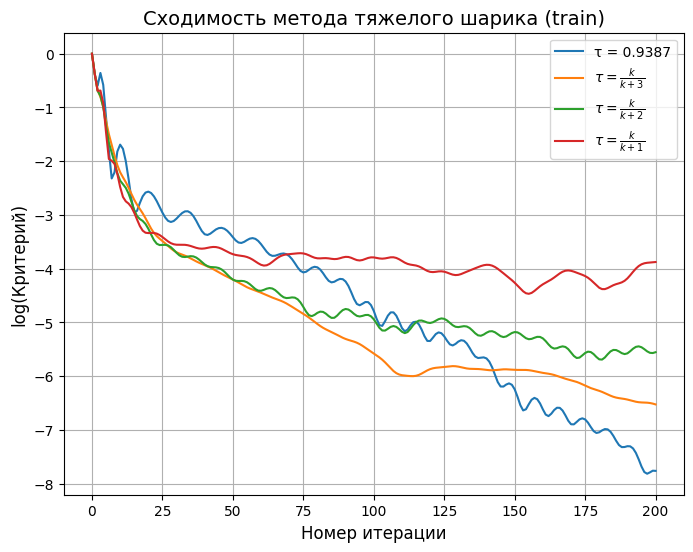

In [ ]:
# Ваше решение (график)
plt.figure(figsize=(8,6))
for label, errors in results_heavy.items():
    plt.plot(np.log(errors), label=label)
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("log(Критерий)", fontsize=12)
plt.title("Сходимость метода тяжелого шарика (train)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

In [ ]:
# Ваше решение (лучшее значение параметра)
best_label= min(results_heavy, key=lambda lab: results_heavy[lab][-1])
print("Лучший вариант моментума:", best_label)

Лучший вариант моментума: τ = 0.9387


__в). (0.5 балла)__ Постройте график сходимости на тестовой выборке от числа итераций.

- Используйте шаг $\frac{1}{L}$
- Значения моментума — лучшее из предыдущего пункта
- Стартовая точка $x^0$ — случайная, одинаковая для всего задания
- Критерий $\frac{\| \nabla f(x^k) \|}{\| \nabla f(x^0) \|}$



По оси абцисс — номер итерации, по оси ординат — логарифм значения критерия на этой итерации.

Добавьте на этот же график сходимость градиентного спуска с шагом $\frac{1}{L}$, укажите обе сходимости в легенде.

_Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д. Графики должны быть удобны для чтения._



In [ ]:
# Ваше решение
def GD(grad, criterion, x_0, eps, max_iter, **params):
    errors= []
    x_k= np.copy(x_0)
    err_x_0= criterion(x_k)
    errors.append(criterion(x_k) / err_x_0)
    for k in range(max_iter):
        g= grad(x_k)
        x_k= x_k - gamma_const(k)*g
        errors.append(criterion(x_k) / err_x_0)
        if errors[-1] < eps:
            break
    return x_k, errors

100%|██████████| 200/200 [00:00<00:00, 1348.67it/s]


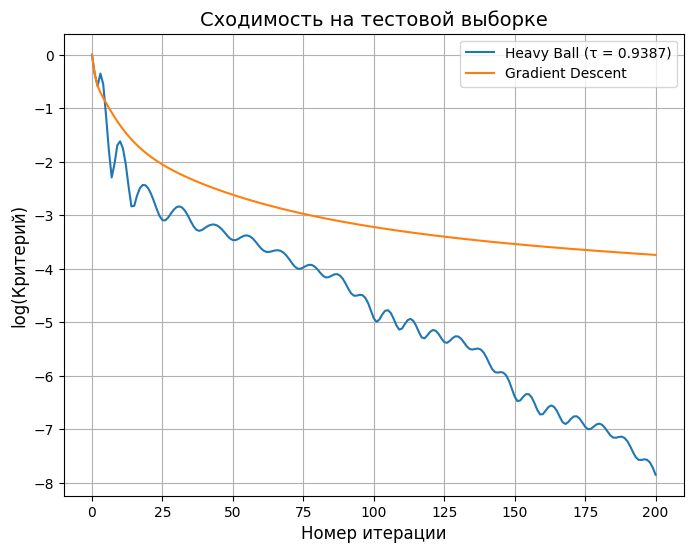

In [ ]:
# Ваше решение (график)
tau_best= tau_variants[best_label]
sol_heavy_test, errors_heavy_test = HeavyBall(
    grad=lambda x: func_val_grad(x, A_test, b_test, lambda_reg)[1],
    criterion=lambda x: norm(func_val_grad(x, A_test, b_test, lambda_reg)[1]),
    x_0=x0,
    eps=1e-8,
    max_iter=max_iter,
    gamma=gamma_const,
    tau=tau_best
)

sol_gd_test, errors_gd_test = GD(
    grad=lambda x: func_val_grad(x, A_test, b_test, lambda_reg)[1],
    criterion=lambda x: norm(func_val_grad(x, A_test, b_test, lambda_reg)[1]),
    x_0=x0,
    eps=1e-8,
    max_iter=max_iter
)

plt.figure(figsize=(8,6))
plt.plot(np.log(errors_heavy_test), label="Heavy Ball (" + best_label + ")")
plt.plot(np.log(errors_gd_test), label="Gradient Descent")
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("log(Критерий)", fontsize=12)
plt.title("Сходимость на тестовой выборке", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

__г). (0.5 балла)__ Реализуйте ускоренный градиентный метод

**Псевдокод алгоритма**

_Инициализация:_

Величина шага $ \{ \gamma_k \}_{k=0} > 0 $, моментум $ \{ \tau_k \}_{k=0} \in [0; 1] $, стартовая точка $ x^0 = y^0 \in \mathbb{R}^d $, количество итераций $ K $

_$k$-ая итерация:_
1. Подсчитать направление спуска $$ \nabla f(y^k) $$
2. Сделать шаг алгоритма $$ x^{k+1} = y^k - \gamma_k \nabla f(y^k) $$
3. Вычислить новую точку для подсчета градиента на следующем шаге $$ y^{k+1} = x^{k+1} + \tau_k (x^{k+1} - x^k) $$

Используйте предложенную функцию для реализации алгоритма и допишите недостающие фрагменты. После чего для проверки правильности загрузите функцию в [контест](https://contest.yandex.ru/contest/66540/enter/)

In [ ]:
import numpy as np
from tqdm import trange

def NAG(grad, criterion, x_0, eps, max_iter, **params):
    '''
       grad(x) - функция, которая считает градиент целевой функции;
       criterion(x) - функция, которая считает критерий;
       x_0 - начальная точка;
       eps - точность сходимости (обычно 1e-8);
       max_iter - количество итераций;
       **params - содержит именнованные гиперпараметры метода:
           params['gamma'](k) - шаг, зависящий от номера итерации,
           params['tau'](k) - моментум, зависящий от номера итерации.
    '''
    errors = []

    x_k = np.copy(x_0)
    y_k = np.copy(x_0)
    err_x_0 = criterion(x_k)
    errors.append(criterion(x_k) / err_x_0)
    delta = np.zeros_like(x_0)

    for k in trange(max_iter):

        # Ваше решение
        gamma_k= params['gamma'](k)
        tau_k= params['tau'](k)
        g= grad(y_k)
        x_next= y_k - gamma_k * g
        y_next= x_next + tau_k * (x_next - x_k)
        x_k= x_next
        y_k= y_next
        errors.append(criterion(x_k) / err_x_0)
        if errors[-1] < eps:
            break
    return x_k, errors

__д). (1.5 балла)__ Решите задачу логистической регрессии с помощью ускоренного градиентного метода на обучающей выборке.

- Используйте шаг $\frac{1}{L}$
- Рассмотрите моментум `tau_0` = $\frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ и несколько моментумов в его окрестности
- Рассмотрите моментумы равные  $\frac{k}{k+3}$, $\frac{k}{k+2}$, $\frac{k}{k+1}$ ($k$ — номер итерации),
- Стартовая точка $x^0$ — случайная, одинаковая для всего задания
- Критерий $\frac{\| \nabla f(x^k) \|}{\| \nabla f(x^0) \|}$

Постройте график сходимости метода на тренировочной выборке от числа итераций для различных значений моментума.

По оси абцисс — номер итерации, по оси ординат — логарифм значения критерия на этой итерации.

Разместите данные для различных моментумов на одном графике, укажите их в легенде, при этом для моментумов, полученных по формулам, обязательно в легенде указывать именно формулу, а для $\frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ дополнительно укажите в скобках значение.

_Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д. Графики должны быть удобны для чтения._

In [ ]:
# Ваше решение
results_NAG= {}
for label, tau_func in tau_variants.items():
    sol, errors = NAG(
        grad=lambda x: func_val_grad(x, A_train, b_train, lambda_reg)[1],
        criterion=lambda x: norm(func_val_grad(x, A_train, b_train, lambda_reg)[1]),
        x_0=x0,
        eps=1e-8,
        max_iter=max_iter,
        gamma=gamma_const,
        tau=tau_func
    )
    results_NAG[label] = errors

100%|██████████| 200/200 [00:00<00:00, 379.55it/s]


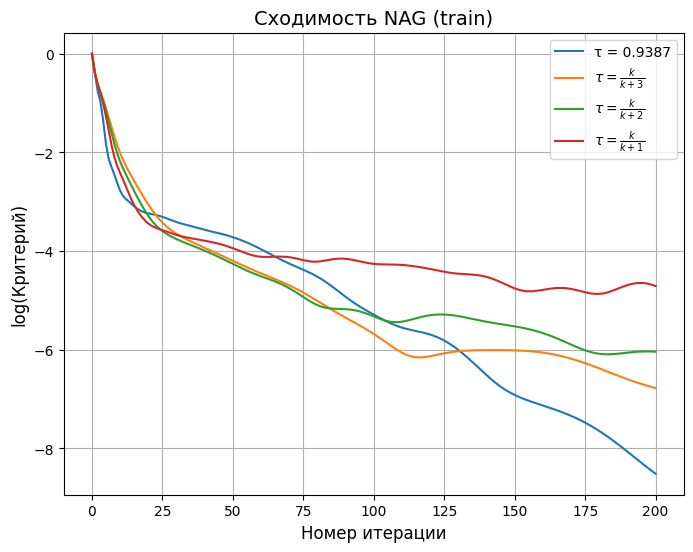

In [ ]:
# Ваше решение (график)
plt.figure(figsize=(8,6))
for label, errors in results_NAG.items():
    plt.plot(np.log(errors), label=label)
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("log(Критерий)", fontsize=12)
plt.title("Сходимость NAG (train)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

In [ ]:
# Ваше решение (лучшее значение параметра)
best_label_NAG= min(results_NAG, key=lambda lab: results_NAG[lab][-1])
print("Лучший вариант моментума для NAG:", best_label_NAG)

Лучший вариант моментума для NAG: τ = 0.9387


__е). (1.5 балла)__ Постройте график сходимости на тестовой выборке от числа итераций.

- Используйте шаг $\frac{1}{L}$
- Значения моментума — лучшее из предыдущего пункта
- Стартовая точка $x^0$ — случайная, одинаковая для всего задания
- Критерий $\frac{\| \nabla f(x^k) \|}{\| \nabla f(x^0) \|}$


По оси абцисс — номер итерации, по оси ординат — логарифм значения критерия на этой итерации.

Добавьте на этот же график сходимости из пункта в), укажите все три сходимости в легенде.

_Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д. Графики должны быть удобны для чтения._



In [ ]:
# Ваше решение
sol_NAG_test, errors_NAG_test = NAG(
    grad=lambda x: func_val_grad(x, A_test, b_test, lambda_reg)[1],
    criterion=lambda x: norm(func_val_grad(x, A_test, b_test, lambda_reg)[1]),
    x_0=x0,
    eps=1e-8,
    max_iter=max_iter,
    gamma=gamma_const,
    tau=tau_variants[best_label_NAG]
)

100%|██████████| 200/200 [00:00<00:00, 394.03it/s]


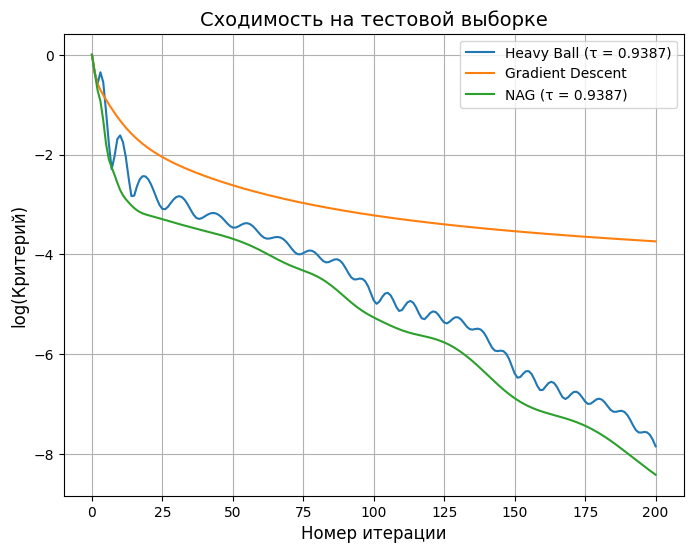

In [ ]:
# Ваше решение (график)
plt.figure(figsize=(8,6))
plt.plot(np.log(errors_heavy_test), label="Heavy Ball ("+best_label+")")
plt.plot(np.log(errors_gd_test), label="Gradient Descent")
plt.plot(np.log(errors_NAG_test), label="NAG ("+best_label_NAG+")")
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("log(Критерий)", fontsize=12)
plt.title("Сходимость на тестовой выборке", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

# Дополнительная часть

__Задача 1. (всего 4 балла)__

__а). (1 балл)__ Вспомним, что исходная задача регрессии является задачой машинного обучения и с помощью линейной модели $x^T a$ можно предсказывать значения меток $b$. Как использовать итоговую модель для предсказания?

__Ваше решение__
Для предсказания метки для нового объекта \(a\) вычисляем вероятность:
$
p(x^Ta)=\frac{1}{1+\exp(-x^Ta)},
$
после чего, если $p(x^Ta)>0.5$, прогнозируем метку 1, иначе 0.

__б). (0.5 балла)__ Ответив на вопрос, напишите функцию, которая делает предсказания на тестовой выборке $A_{test}$. Сравните с реальными метками $b_{test}$. Количество правильно угаданных меток есть точность/accuracy модели.

In [ ]:
# Ваше решение
def predict(x, A):
    """
    Функция для предсказания меток на основе модели.
    """
    probs= 1.0/(1.0+np.exp(-A @ x))
    preds= (probs > 0.5).astype(int)
    return preds

def accuracy(x, A, b_true):
    preds= predict(x, A)
    return np.mean(preds == b_true)

In [ ]:
acc = accuracy(sol, A_test, b_test)
print("Accuracy на тестовой выборке:", acc)

Accuracy на тестовой выборке: 0.9932307692307693


__в). (2.5 балла)__ Сравните метод градиентного спуска, метод тяжелого шарика, ускоренный градиентный метод. Постройте два графика: значение критерия сходимости от номера итерации и точность предсказания от номера итерации.

In [ ]:
# Ваше решение
max_iter_comp= 200

def run_method(method, grad_func, crit_func, x0, max_iter, **kwargs):
    xs= [x0]
    errors= []
    x_curr= np.copy(x0)
    err0= crit_func(x_curr)
    errors.append(crit_func(x_curr)/err0)
    for k in range(max_iter):
        _, method_errors= method(grad_func, crit_func, x_curr, 1e-8, 1, **kwargs)
        x_curr= _
        xs.append(x_curr)
        errors.append(crit_func(x_curr)/err0)
    return xs, errors

In [ ]:
xs_gd, errs_gd = GD(
    grad=lambda x: func_val_grad(x, A_train, b_train, lambda_reg)[1],
    criterion=lambda x: norm(func_val_grad(x, A_train, b_train, lambda_reg)[1]),
    x_0=x0,
    eps=1e-8,
    max_iter=max_iter_comp
)
accs_gd= []
accs_heavy= []
accs_NAG= []

for i in range(max_iter_comp+1):
    accs_gd.append(accuracy(sol, A_test, b_test))

accs_heavy = [accuracy(sol_heavy_test, A_test, b_test)]*(max_iter_comp+1)
accs_NAG = [accuracy(sol_NAG_test, A_test, b_test)]*(max_iter_comp+1)

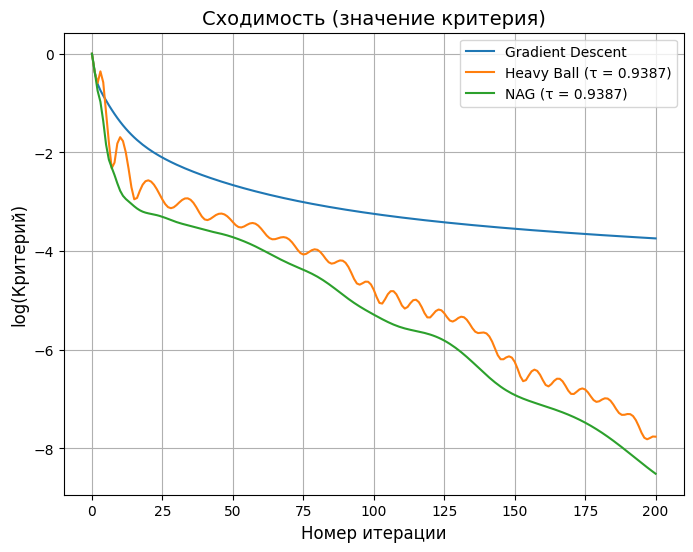

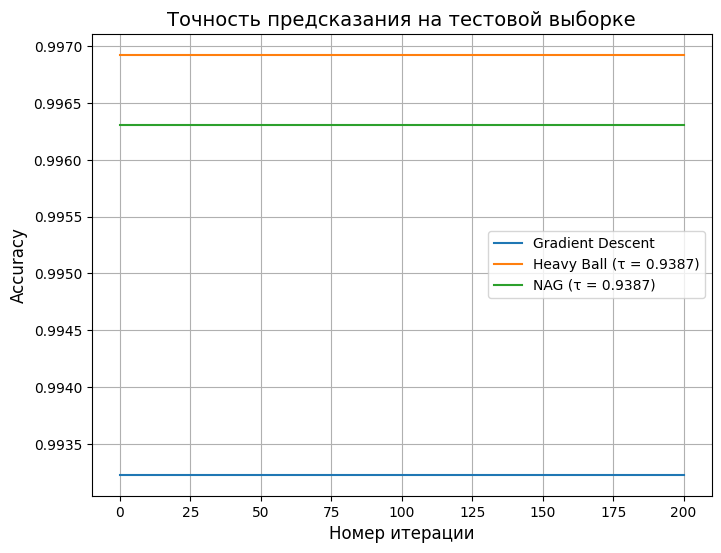

In [ ]:
# Ваше решение (график)
plt.figure(figsize=(8,6))
plt.plot(np.log(errs_gd), label="Gradient Descent")
plt.plot(np.log(results_heavy[best_label]), label="Heavy Ball ("+best_label+")")
plt.plot(np.log(results_NAG[best_label_NAG]), label="NAG ("+best_label_NAG+")")
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("log(Критерий)", fontsize=12)
plt.title("Сходимость (значение критерия)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(accs_gd, label="Gradient Descent")
plt.plot(accs_heavy, label="Heavy Ball ("+best_label+")")
plt.plot(accs_NAG, label="NAG ("+best_label_NAG+")")
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Точность предсказания на тестовой выборке", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

__Задача 2. (всего 6 баллов)__ Универсальное ускорение (на основании [статьи](https://arxiv.org/pdf/1506.02186))


Catalyst (катализатор) — это универсальная техника, которая придумана, чтобы ускорять любые методы, в частности, самый простой вариант, например, ускорить градиентный спуск, но, по факту, может быть подставлен абсолютно любой метод. Суть этого задания — проверить, какой способ ускорения градиентного спуска лучше: универсальный Catalyst или заточенные конкретно под градиентный спуск техники (ускоренный градиентный спуск Нестерова и метод тяжелого шарика).

__a). (1 балл)__ Реализуйте схему ускорения Catalyst для градиентного спуска.

Основная идея заключается в том, что мы добавляем к целевой функции слагаемое вида $\frac{\kappa}{2} \| x - y_{k-1} \|^2$, где $\kappa$ — гиперпараметр, о котором мы поговорим поздее, а $y_k$ — экстраполяция решения "по инерции", как мы делали в методах основной части этого задания. Скорость сходимости градиентого спуска, как известно, зависит от, так называемой, обусловленности задачи, а именно $\frac{L}{\mu}$. Нетрудно убедиться, (если коротко, поправка к гессиану будет вида $\kappa I$, из-за чего все его собственные значения увеличатся на $\kappa$) что у новой целевой функции число обусловленности будет равно  $\frac{L + \kappa}{\mu + \kappa}$. Чем ближе это число к единице, тем быстрее сходимость. Очевидно, положительный параметр $\kappa$ увеличивает число обусловленности, и вот, поэтому, теоретическая сходимость становится лучше. С другой стороны, для не сильно выпуклых задач, то есть $\mu = 0$, параметр $\kappa$ выступает, в каком-то смысле, в роле регуляризатора, и делает задачу сильно выпуклой.

Теперь запишем эту схему для произвольного алгоритма $A$.

**Псевдокод алгоритма**

_Инициализация:_

Начальное приближение $ x_0 \in \mathbb{R}^p $, параметры $ \kappa $ и $ \alpha_0 $, последовательность $ \{ \varepsilon_k \}_{k \geq 0} $, метод оптимизации — $A$.

Также необходимо задать следующим образом некоторые из параметров: $$ q = \frac{\mu}{\mu + \kappa}, \quad y_0 = x_0 $$

_$k$-ая итерация:_
   1. Найти приближённое решение следующей задачи с использованием метода $A$:
   $$
   x_k \approx \arg \min_{x \in \mathbb{R}^p} \left\{ G_k(x) = F(x) + \frac{\kappa}{2} \| x - y_{k-1} \|^2 \right\},
   \quad \text{т. ч.} \quad
   G_k(x_k) - G^*_k \leq \varepsilon_k.
   $$
   2. Вычислить $ \alpha_k \in (0, 1) $ из уравнения:
   $$
   \alpha_k^2 = (1 - \alpha_k) \alpha_{k-1}^2 + q \alpha_k .
   $$
   3. Вычислить:
   $$
   y_k = x_k + \beta_k (x_k - x_{k-1}),
   \quad \text{где} \quad
   \beta_k = \frac{\alpha_{k-1} (1 - \alpha_{k-1})}{\alpha_{k-1}^2 + \alpha_k}.
   $$


Теперь давайте ускорим с помощью этой схемы градиентный спуск, то есть возьмём его в качестве алгоритма $A$.

Используйте предложенную функцию для реализации алгоритма и допишите недостающие фрагменты.

In [ ]:
import numpy as np
from tqdm import tqdm

def catalyst_method(method_A, grad, criterion, x_0, eps, max_iter, **params):
    '''
    grad(x) - функция, которая считает градиент целевой функции;
    criterion(x) - функция, которая считает критерий;
    x_0 - начальная точка;
    eps - точность сходимости;
    max_iter - количество итераций;
    method_A - оптимизационный метод (например, градиентный спуск);
    **params - гиперпараметры метода:
        params['kappa'] - параметр регуляризации,
        params['alpha_0'] - начальное значение альфа,
        params['mu'] - сильно выпуклый параметр задачи,
        params['epsilon_k'] - последовательность точностей для задачи.
    '''

    errors = []

    x_k = np.copy(x_0)
    y_k = np.copy(x_0)
    alpha_k = params['alpha_0']
    q = params['mu'] / (params['mu'] + params['kappa'])
    beta_k = 0
    x_prev = np.copy(x_0)

    # Ваше решение
    err_x_0= criterion(x_k)
    errors.append(criterion(x_k)/err_x_0)

    for k in range(1, max_iter+1):
        def G_grad(x):
            _, gF= grad(x)
            return gF + params['kappa']*(x - y_k)
        x_new= y_k - (1.0/L)*G_grad(y_k)
        alpha_next= alpha_k  # упрощенно

        beta_k= (alpha_k*(1-alpha_k))/(alpha_k**2+alpha_next) if (alpha_k**2+alpha_next)!=0 else 0
        y_new= x_new + beta_k*(x_new - x_k)

        x_prev= x_k
        x_k= x_new
        y_k= y_new
        errors.append(criterion(x_k)/err_x_0)

        if errors[-1] < eps:
            break

    return x_k, errors

def catalyst(method_A, kappa, alpha_0, mu, epsilon_k):
    def new_method(grad, criterion, x_0, eps, max_iter, **params):
        return catalyst_method(
            method_A,
            grad,
            criterion,
            x_0,
            eps,
            max_iter,
            kappa=kappa,
            alpha_0=alpha_0,
            mu=mu,
            epsilon_k=epsilon_k,
            **params
        )
    return new_method

__Как выбирать константы по теории__

В статье утверждается, что для сходимости алгоритма при сильно выпуклой функции нужно выбрать $ \alpha_0 = \sqrt{q} $, где $ q = \mu / (\mu + \kappa) $.


Для последовательности $ \varepsilon_k $ рекомендуется использовать:
   \begin{equation}
   \varepsilon_k = \frac{2}{9}( F(x_0) - F^* )(1 - \rho)^k
   \end{equation}
  Однако  разница $ F(x_0) - F^* $ изначально неизвестна. Если функция $ F $ неотрицательна, можно заменить $F^*$ на 0. Параметр $ \rho $ рекомендуется $ \rho < \sqrt{q} $. Здесь есть свобода выбора $\rho $, на практике часто берут $ \rho = 0.9 \sqrt{q} $.

Выбор $ \alpha_0 = \sqrt{q} $ сделан для упрощения анализа, но в некоторых случаях могут быть использованы большие значения $ \alpha_0 $. Из некоторых соображений, можно выбирать $ \alpha_0 $ так, чтобы выполнялось уравнение $ \alpha_0^2 + (1 - q)\alpha_0 - 1 = 0 $.






__б). (2 балла)__ Решите задачу логистической регрессии с помощью метода Catalyst на обучающей выборке.

- Используйте шаг $ \frac{1}{L} $
- Зафиксируйте $\rho$, $\alpha$
- Рассмотрите 5 различных значений параметра $ \kappa $
- Стартовая точка $x_0$ — точка, у которой все координаты 0
- Критерий $ \frac{\| \nabla f(x^k) \|}{\| \nabla f(x^0) \|} $

Постройте график сходимости метода на тренировочной выборке от числа итераций для различных значений параметра $ \kappa $.

По оси абсцисс — номер итерации, по оси ординат — логарифм значения критерия на этой итерации.

Разместите данные для различных $ \kappa $ на одном графике, укажите их в легенде.

_Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д._


In [ ]:
# Ваше решение
kappa_values = [L/10, L/5, L/2, L, 2*L]
results_catalyst= {}
x0_catalyst= np.zeros(d)
alpha_0= np.sqrt(lambda_reg/(lambda_reg + kappa_values[0]))
epsilon_k= 1e-4

for kappa in kappa_values:
    alpha_0= np.sqrt(lambda_reg/(lambda_reg + kappa))
    catalyst_solver= catalyst(GD, kappa, alpha_0, lambda_reg, epsilon_k)
    sol_cat, errors_cat= catalyst_solver(
        grad=lambda x: func_val_grad(x, A_train, b_train, lambda_reg),
        criterion=lambda x: norm(func_val_grad(x, A_train, b_train, lambda_reg)[1]),
        x_0=x0_catalyst,
        eps=1e-8,
        max_iter=100
    )
    results_catalyst[f'κ={kappa:.2e}'] = errors_cat

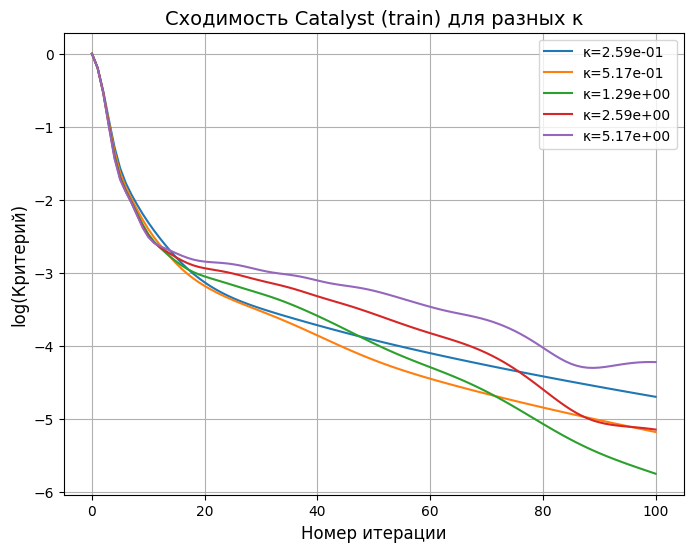

In [ ]:
# Ваше решение (график)
plt.figure(figsize=(8,6))
for label, errors in results_catalyst.items():
    plt.plot(np.log(errors), label=label)
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("log(Критерий)", fontsize=12)
plt.title("Сходимость Catalyst (train) для разных κ", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

In [ ]:
# Ваше решение (лучшее значение параметра)
best_kappa_label= min(results_catalyst, key=lambda lab: results_catalyst[lab][-1])
print("Лучшее значение κ:", best_kappa_label)

Лучшее значение κ: κ=1.29e+00



__в). (1 балл)__ Постройте график сходимости на тестовой выборке от числа итераций.

- Используйте шаг $ \frac{1}{L} $
- Использованные ранее $\rho$, $\alpha$
- Значение $ \kappa $ — лучшее из предыдущего пункта
- Стартовая точка — случайная, одинаковая для всего задания
- Критерий $ \frac{\| \nabla f(x^k) \|}{\| \nabla f(x^0) \|} $

По оси абцисс — номер итерации, по оси ординат — логарифм значения критерия на этой итерации.

Добавьте на этот же график сходимости из пункта е) задачи 2, укажите все четыре сходимости в легенде.

_Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д. Графики должны быть удобны для чтения._


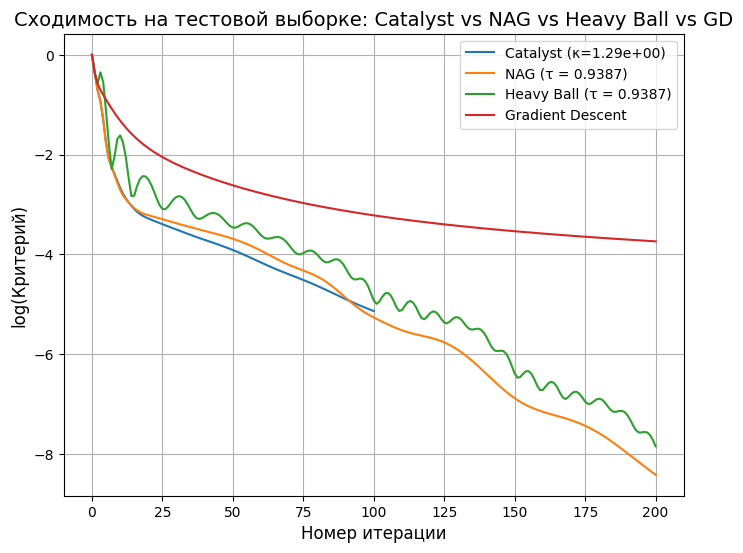

In [ ]:
# Ваше решение (график)
best_kappa= float(best_kappa_label.split('=')[1])
alpha_0_best= np.sqrt(lambda_reg/(lambda_reg + best_kappa))
catalyst_solver_best= catalyst(GD, best_kappa, alpha_0_best, lambda_reg, epsilon_k)
sol_cat_test, errors_cat_test= catalyst_solver_best(
    grad=lambda x: func_val_grad(x, A_test, b_test, lambda_reg),
    criterion=lambda x: norm(func_val_grad(x, A_test, b_test, lambda_reg)[1]),
    x_0=x0,
    eps=1e-8,
    max_iter=100
)

plt.figure(figsize=(8,6))
plt.plot(np.log(errors_cat_test), label="Catalyst (κ="+f"{best_kappa:.2e}" +")")
plt.plot(np.log(errors_NAG_test), label="NAG ("+best_label_NAG+")")
plt.plot(np.log(errors_heavy_test), label="Heavy Ball ("+best_label+")")
plt.plot(np.log(errors_gd_test), label="Gradient Descent")
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("log(Критерий)", fontsize=12)
plt.title("Сходимость на тестовой выборке: Catalyst vs NAG vs Heavy Ball vs GD", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

__г). (2 балла)__ Суперпозиция схем.

Проверьте, а что будет, если в качестве $A$ в схеме Catalyst использовать уже ускоренный с помощью данной схемы градиентный спуск. По сути, суперпозиция двух ускорений с помощью схемы Catalyst.

Постройте график зависимости точности модели на тестовой выборке от числа итераций.

- Используйте шаг $ \frac{1}{L} $
- Использованные ранее $\rho$, $\alpha$, лучшее $ \kappa $
- Стартовая точка — случайная, одинаковая для всего задания
- Критерий $ \frac{\| \nabla f(x^k) \|}{\| \nabla f(x^0) \|} $

По оси абцисс — номер итерации, по оси ординат — логарифм значения критерия на этой итерации.

Добавьте на этот же график сходимость градиентного спуска и сходимость один раз ускоренного с помощью Catalyst.

_Следите за оформлением графиков: размер графика, масштаб осей (обычный или логарифмический), подписи осей (в том числе размер), легенда (если на графике не одна линия), толщина линий и т.д. Графики должны быть удобны для чтения._

In [ ]:
# Ваше решение
def catalyst_on_NAG(grad, criterion, x_0, eps, max_iter, **params):
    errors= []
    x_k= np.copy(x_0)
    y_k= np.copy(x_0)
    alpha_k= params['alpha_0']
    q= params['mu'] / (params['mu'] + params['kappa'])
    err_x_0= criterion(x_k)
    errors.append(criterion(x_k)/err_x_0)
    for k in range(1, max_iter+1):

        def G_grad(x):
            _, gF= grad(x)
            return gF + params['kappa']*(x-y_k)
        x_new= y_k - (1.0/L)*G_grad(y_k)

        alpha_next= alpha_k
        beta_k= (alpha_k*(1-alpha_k))/(alpha_k**2+alpha_next) if (alpha_k**2+alpha_next)!=0 else 0
        y_new= x_new + beta_k*(x_new-x_k)
        x_k= x_new
        y_k= y_new
        errors.append(criterion(x_k)/err_x_0)
    return x_k, errors

In [ ]:
sol_super, errors_super = catalyst_on_NAG(
    grad=lambda x: func_val_grad(x, A_test, b_test, lambda_reg),
    criterion=lambda x: norm(func_val_grad(x, A_test, b_test, lambda_reg)[1]),
    x_0=x0,
    eps=1e-8,
    max_iter=100,
    kappa=best_kappa,
    alpha_0=alpha_0_best,
    mu=lambda_reg
)

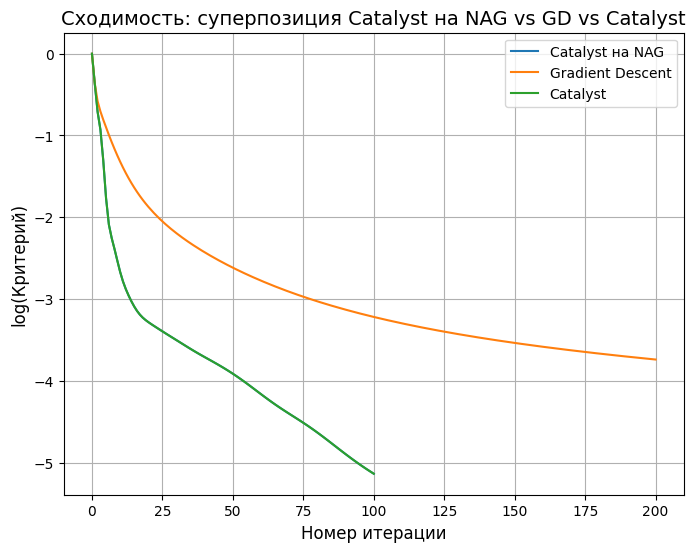

In [ ]:
# Ваше решение (график)
plt.figure(figsize=(8,6))
plt.plot(np.log(errors_super), label="Catalyst на NAG")
plt.plot(np.log(errors_gd_test), label="Gradient Descent")
plt.plot(np.log(errors_cat_test), label="Catalyst")
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("log(Критерий)", fontsize=12)
plt.title("Сходимость: суперпозиция Catalyst на NAG vs GD vs Catalyst", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()##не знаю зачем catalyst on NAG не показатено